In [1]:
!pip install networkx

In [35]:
import pandas as pd
import itertools
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
from scipy.optimize import curve_fit

A faire : ajouter une intro avec titre + rappel bref de l'objectif du projet
+ préciser le champ de l'étude (NYC?)

# 1.Téléchargement des données et constitution du dataframe

In [4]:
path_data_check_in='data/dataset_TSMC2014_NYC.txt'
path_data_users='data/UbiComp2016_UserProfile_NYC.txt'

df_check_in=pd.read_csv(path_data_check_in,sep='\t',encoding='latin-1',header=None,names=['user_id','location_id','location_type_ID', 'location_type_name','latitude','longitude','timezone','timestamp'])
df_users = pd.read_csv(path_data_check_in,sep='\t',encoding='latin-1',header=None,names=['user_id','gender','nb_twitter_friends', 'nb_twitter_followers'])


In [ ]:
#Exploration des données

df_check_in.head()
df_users.head()

df_check_in.isna().sum()
df_users.isna().sum()

# Les df ne contiennent aucun na et les variables d'intérêt sont bien présentes

user_id                 0
gender                  0
nb_twitter_friends      0
nb_twitter_followers    0
dtype: int64

# 2. Etude du réseau

## 2.1 Le réseau complet

Nous commencerons par constituer un réseau tel que:
- les noeuds soient constitués d'établissements visités plus d'une fois
- ces établissements soient connectés par une arête si ils ont été visités par au moins un utilisateur commun


In [10]:
# Constitution d'un dataframe avec deux colonnes location_id (i) et liste de tous les check-ins pour cet utilisateur(ii)
dfagg=df_check_in.groupby('user_id',as_index=False)['location_id'].agg(list).rename(columns={'location_id':'checkins'})

# Ajout de le colonne nbre de check-in
dfagg['n_checkins']=dfagg['checkins'].apply(lambda x: len(x))

# On ne conserve que les utilisateurs qui ont visité au moins deux lieux 
# (condition nécessaire pour créer un lien entre deux établissements)
dfagg=dfagg[dfagg['n_checkins']>1]

dfagg

,user_id,checkins,n_checkins
0,1,"[4abc1f51f964a520798620e3, 4d4ac10da0ef54814b6...",106
1,2,"[4ef372169adf60f8399b4bd7, 49cbb6f9f964a5200f5...",152
2,3,"[4e691e82b9930387355c629d, 49d6de35f964a520085...",118
3,4,"[4a6a3991f964a520e0cc1fe3, 4b376908f964a520ef4...",175
4,5,"[4beb37c0a9900f47b68e1740, 4dd417bcfa7645a53c9...",111
...,...,...,...
1078,1079,"[40df5f80f964a52098011fe3, 4a78b7faf964a5203ee...",136
1079,1080,"[4e5d901788771beefa9b2487, 4a96f983f964a520c82...",128
1080,1081,"[4c34858f66e40f47009fc98b, 50cec459e4b06f07e41...",100
1081,1082,"[4c2a849357a9c9b693a1f467, 4aa5c657f964a5206d4...",258


In [28]:
# Création du réseau

# A partir de la liste de la colonne checkins: liste de toutes les combinaisons possibles de deux lieux visités par un utilisateur commun
dfagg['edges']=dfagg['checkins'].apply(lambda x: list(itertools.combinations(x,2)))

def flatten(l):
    return [item for sublist in l for item in sublist]

edges=flatten(dfagg['edges'].tolist())

# Création du réseau à partir de la liste d'arêtes edges
G=nx.Graph()
G.add_edges_from(edges)

# Suppression des self-loops
G.remove_edges_from(nx.selfloop_edges(G))

In [29]:
print(f"Nombre de lieux (nœuds) dans le réseau : {G.number_of_nodes()}")
print(f"Nombre de connexions (arêtes) entre lieux : {G.number_of_edges()}")
print(f"Densité du réseau (proportion de liens réels / possibles) : {nx.density(G):.4f}")
print(f"Le réseau est-il entièrement connecté ? : {nx.is_connected(G)}")

Nombre de lieux (nœuds) dans le réseau : 38333
Nombre de connexions (arêtes) entre lieux : 4729505
Densité du réseau (proportion de liens réels / possibles) : 0.0064
Le réseau est-il entièrement connecté ? : True


Le réseau d'établissements est très peu dense (seulement 0,64% des arêtes possibles sont effectivement présentes). Ce résultat était-il prévisible? Compte tenu du nombre important de lieux répertoriés ainsi que des contraintes géographiques et des caractéristiques des comportements humains (tendance à visiter les lieux proches ou recommandés). Nous pouvons faire l'hypothèse que le réseau est structuré en différents îlots, reliés entre eux par quelques hubs servant de ponts, liaisons qui expliquent que le réseau reste entièrement connecté.

A faire : représentation du réseau

In [30]:
# Préparation des données pour un histogramme en échelle logarithmique
def logBinning(degreeList,nbin):
    kmin=min(degreeList)
    kmax=max(degreeList)
    logBins = np.logspace(np.log10(kmin), np.log10(kmax),num=nbin)
    logBinDensity, binedges = np.histogram(degreeList, bins=logBins, density=True)
    logBins = np.delete(logBins, -1)
    return logBinDensity, logBins


# Ajustement d'une loi puissance : f(x)= bx^a
def powerLaw(x, a, b):
    return b*x**(a)

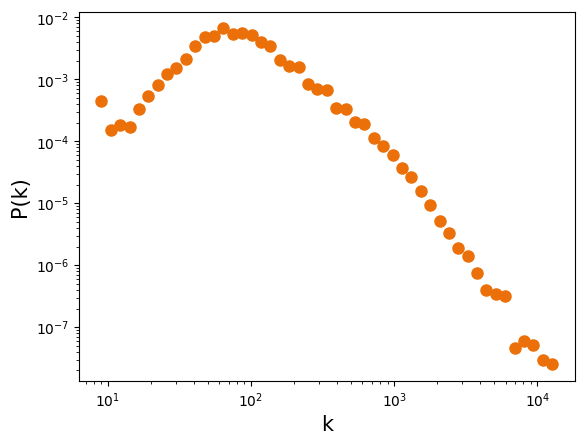

In [31]:
# Liste des degrés des noeuds du réseau
kDict=dict(G.degree())
kValues=list(kDict.values())

pk,k=logBinning(kValues,50)
plt.loglog(k,pk,'o',color='#EB7009',markersize=8)
plt.xlabel('k',size=15)
plt.ylabel('P(k)',size=15)
plt.show()

La loi puissance ne semble vérifiée que pour k>100 (hyp: présence de gros hubs mais peu de lieux avec très peu de connections?)
Question: est-ce que cela vaut la peine de creuser ou l'étude du micro-réseau et du macro-réseau compléteront-elles directement ce premier graphique (présence ou non d'une loi puissance dans l'un ou l'autre de ces sous-réseaux)

### Degree mixing
Objectif: répondre à la question qui se connecte avec qui?

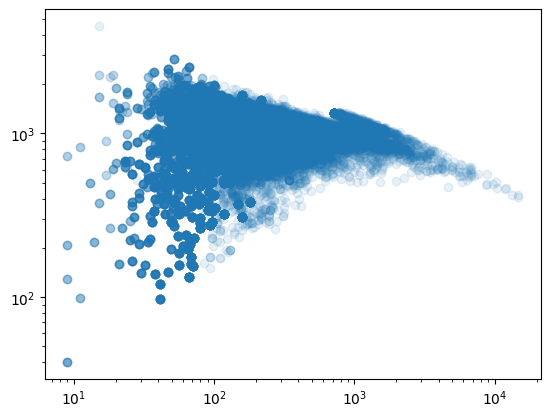

In [36]:
# Calcul du degré moyen de ses voisins pour chaque noeud
knn={}
for n in G.nodes():
    neighbors_degrees=[kDict[v] for v in G.neighbors(n)]
    knn[n]=np.mean(neighbors_degrees)


# Tracé de (k, neighbors_degrees_mean )
xx=[]
yy=[]
for n in knn.keys():
    xx.append(kDict[n])
    yy.append(knn[n])

plt.loglog(xx,yy,'o',alpha=0.1)

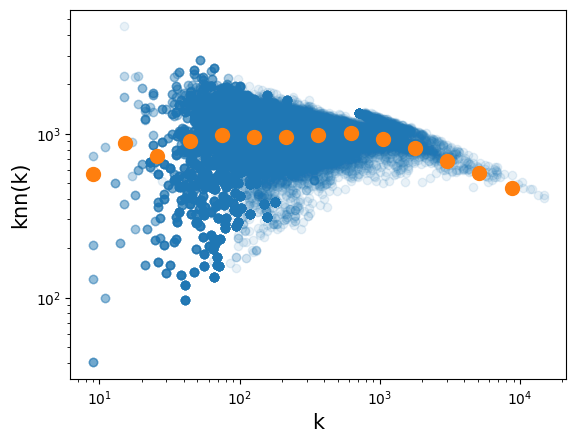

In [ ]:
#  Nous regroupons les données dans des log-bins et nous traçons la moyenne de $knn$ pour chaque log-bin. 
xx=[]
yy=[]
for n in knn.keys():
    xx.append(kDict[n])
    yy.append(knn[n])

plt.loglog(xx,yy,'o',alpha=0.1)
logBins=np.logspace(np.log2(np.min(xx)),np.log2(np.max(xx)),base=2,num=15)
#if I use np.linspace I will have linear bins
ybin,xbin,binnumber=scipy.stats.binned_statistic(xx,yy,statistic='mean',bins=logBins)
plt.loglog(xbin[:-1],ybin,'o',markersize=10)

plt.xlabel('k',size=15)
plt.ylabel('knn(k)',size=15)
plt.show()

Il semblerait que tous les établissements soient connectés à des hubs.

### La propriété rich-club

La courbe est croissante sur la partie droite : plus un lieu est populaire, plus il a de chances d'être connecté à un autre lieu populaire (n'est-ce pas un simple effet mathématique du à l'augmentation du nombre de connexions?) Les lieux peu connectés semblent isolés, ce qui pourrait indiquer avec le graphique précédent qu'ils sont connectés à des hubs mais ne se connectent pas entre eux. A partir d'un certain seuil de popularité tous les lieux semblent connectés entre eux.

Pour s'assurer que l'hyperconnectivité des lieux les plus connectés n'est pas du à un simple effet mathématique, il faudrait comparer cette courbe à un réseau aléatoire.



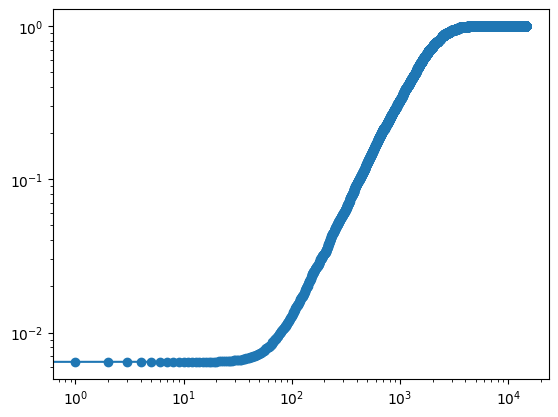

In [32]:
rc = nx.rich_club_coefficient(G, normalized=False, seed=42)
plt.loglog(rc.keys(),rc.values(),'o-')

Comparaison avec un réseau aléatoire

L'IA conseillait de créer un réseau random avec nswap (en commentaire), j'ai préféré un réseau BA comme vu en cours qui crée naturellement des hubs. Le choix est dicutable comme nous n'avons pas de loi puissance, mais c'est une façon de se fixer les idées en première approche avec une interprétation simple du réseau random créé.

On observe une synergie entre les lieux qui ont entre 100 et 200 connections notamment : les utilisateurs ont tendance à naviguer entre ces lieux. La courbe redescend ensuite (et passe même en-dessous de la ligne représentant le modèle random(modèle BA dans ce cas)) : interprétation possible : les super_hubs sont connectés avec tout le monde.

<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_11453/2730399516.py:31: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\phi_{real} / \phi_{rand}$')


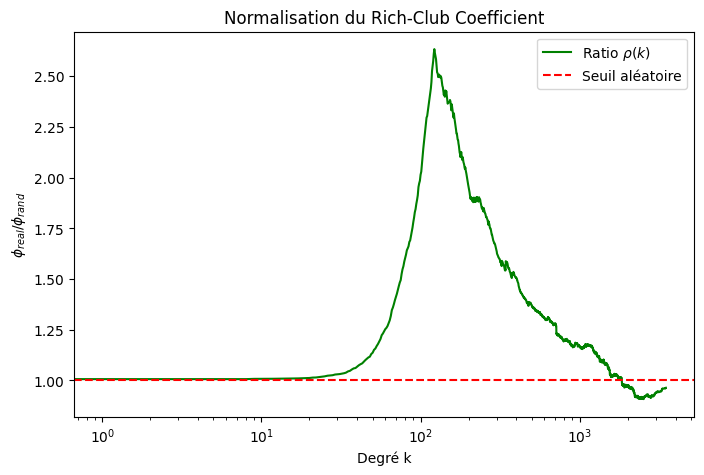

In [41]:


#  Création une version aléatoire de votre graphe G
# nswap définit le nombre de mélanges (plus il est haut, plus c'est aléatoire)
#G_random = nx.random_reference(G, nswap=G.number_of_edges() * 2, seed=42)

# Calculer le rich-club pour les deux
rc_real = nx.rich_club_coefficient(G, normalized=False)
#rc_rand = nx.rich_club_coefficient(G_random, normalized=False)

# N : nombre de nœuds de votre graphe réel
# m : nombre d'arêtes à attacher pour chaque nouveau nœud
# (On estime m par : nombre_total_aretes / nombre_total_noeuds)
N = G.number_of_nodes()
m = int(G.number_of_edges() / N)

G_ba = nx.barabasi_albert_graph(N, m)

# Calcul du rich-club pour comparer
rc_ba = nx.rich_club_coefficient(G_ba, normalized=False)

# Calculer le ratio de normalisation (rho)
# On s'assure de ne comparer que les degrés présents dans les deux
common_k = sorted(set(rc_real.keys()) & set(rc_ba.keys()))
rho = [rc_real[k] / rc_ba[k] for k in common_k]

#  Tracer le résultat
plt.figure(figsize=(8, 5))
plt.plot(common_k, rho, 'g-', label="Ratio $\\rho(k)$")
plt.axhline(y=1, color='r', linestyle='--', label="Seuil aléatoire")
plt.xscale('log')
plt.xlabel('Degré k')
plt.ylabel('$\phi_{real} / \phi_{rand}$')
plt.title('Normalisation du Rich-Club Coefficient')
plt.legend()
plt.show()